# Reproduced prefix trade-off figure

Recreates the provided general-capability versus concept-score plot. The Prompt baseline is shown as a purple square and labeled directly; the figure is saved as a PDF under `figs/`.

Saved /home/xzascc/Documents/code/Prefix/figs/reproduced_prefix_tradeoff.pdf


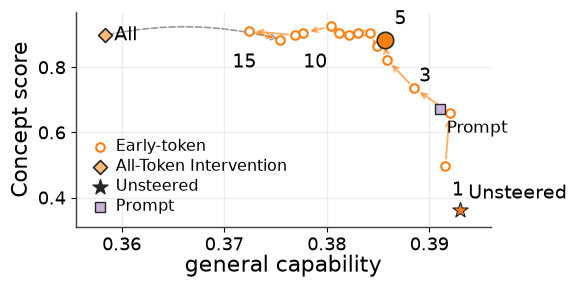

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from io import StringIO
from pathlib import Path

CSV_DATA = """series,prefix_len,general_capability,concept_score
Early-token,1,0.391573,0.498305
Early-token,2,0.391981,0.661017
Early-token,3,0.388518,0.735593
Early-token,4,0.385871,0.823729
Early-token,5,0.385667,0.884746
Early-token,6,0.384852,0.864407
Early-token,7,0.384241,0.905085
Early-token,8,0.383019,0.905085
Early-token,9,0.382205,0.898305
Early-token,10,0.381186,0.905085
Early-token,11,0.380372,0.925424
Early-token,12,0.377724,0.905085
Early-token,13,0.376909,0.898305
Early-token,14,0.372429,0.911864
Early-token,15,0.375484,0.884746
All-Token Intervention,,0.358376,0.898305
Unsteered,,0.392999,0.362712
Prompt,,0.390999,0.6732712
"""

df = pd.read_csv(StringIO(CSV_DATA))
early = df[df["series"] == "Early-token"].copy().sort_values("prefix_len")
all_pt = df[df["series"] == "All-Token Intervention"].iloc[0]
un_pt = df[df["series"] == "Unsteered"].iloc[0]
prompt_pt = df[df["series"] == "Prompt"].iloc[0]

orange = "#ff7f0e"
prompt_color = "#7B4FA3"

fig, ax = plt.subplots(figsize=(5.72, 2.84), dpi=100)

# Dashed gray curve: All-token -> long-prefix steering
curved = FancyArrowPatch(
    (all_pt.general_capability, all_pt.concept_score),
    (
        early.loc[early.prefix_len.eq(15), "general_capability"].item(),
        early.loc[early.prefix_len.eq(15), "concept_score"].item(),
    ),
    connectionstyle="arc3,rad=-0.12",
    arrowstyle="->",
    linestyle="--",
    mutation_scale=9,
    linewidth=1.2,
    color="0.55",
    alpha=0.9,
    zorder=1,
)
ax.add_patch(curved)

# Orange early-token trajectory
xy = early[["general_capability", "concept_score"]].to_numpy()
for (x0, y0), (x1, y1) in zip(xy[:-1], xy[1:]):
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.4,
            color=orange,
            alpha=0.62,
            shrinkA=5,
            shrinkB=5,
            mutation_scale=9,
        ),
        zorder=2,
    )

ax.scatter(
    early["general_capability"],
    early["concept_score"],
    facecolors="white",
    edgecolors=orange,
    s=38,
    linewidths=1.5,
    label="Early-token",
    zorder=4,
)

ax.scatter(
    [all_pt.general_capability],
    [all_pt.concept_score],
    marker="D",
    s=50,
    facecolors="#ffbb78",
    edgecolors="0.15",
    linewidths=1.2,
    label="All-Token Intervention",
    zorder=5,
)

ax.scatter(
    [un_pt.general_capability],
    [un_pt.concept_score],
    marker="*",
    s=130,
    facecolors="0.15",
    edgecolors="0.15",
    linewidths=0.9,
    label="Unsteered",
    zorder=5,
)

# Orange inner star, matching the source figure
ax.scatter(
    [un_pt.general_capability],
    [un_pt.concept_score],
    marker="*",
    s=55,
    facecolors=orange,
    edgecolors=orange,
    linewidths=0.5,
    zorder=6,
)

# Prompt baseline
ax.scatter(
    [prompt_pt.general_capability],
    [prompt_pt.concept_score],
    marker="s",
    s=58,
    facecolors="#c7b4d8",
    edgecolors="0.15",
    linewidths=1.0,
    label="Prompt",
    zorder=6,
)

# Annotations
ax.text(all_pt.general_capability + 0.0009, all_pt.concept_score, "All",
        ha="left", va="center", fontsize=14)
ax.text(0.3708, 0.785, "15", ha="left", va="bottom", fontsize=14)
ax.text(0.3777, 0.785, "10", ha="left", va="bottom", fontsize=14)
ax.text(0.3866, 0.918, "5", ha="left", va="bottom", fontsize=14)
ax.text(0.3890, 0.742, "3", ha="left", va="bottom", fontsize=14)
ax.text(0.3922, 0.392, "1", ha="left", va="bottom", fontsize=14)
ax.text(un_pt.general_capability + 0.0008, un_pt.concept_score + 0.02,
        "Unsteered", ha="left", va="bottom", fontsize=14)
ax.text(prompt_pt.general_capability + 0.0007, prompt_pt.concept_score - 0.035,
        "Prompt", ha="left", va="top", fontsize=12)

ax.set_xlabel("general capability", fontsize=16, labelpad=0)
ax.set_ylabel("Concept score", fontsize=16)
pt5 = early[early["prefix_len"] == 5].iloc[0]
ax.scatter(
    [pt5["general_capability"]],
    [pt5["concept_score"]],
    s=140,
    facecolors=orange,
    edgecolors="0.15",
    linewidths=1.2,
    zorder=6,
)
ax.set_xlim(0.3555, 0.3960)
ax.set_ylim(0.31, 0.97)
ax.set_xticks([0.36, 0.37, 0.38, 0.39])
ax.set_yticks([0.4, 0.6, 0.8])

ax.tick_params(axis="both", labelsize=13)
ax.grid(True, color="0.85", linewidth=1.0, alpha=0.45)

ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    frameon=False,
    fontsize=11.5,
    handlelength=1.0,
    handletextpad=0.5,
    borderpad=0.0,
    labelspacing=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("0.25")
ax.spines["bottom"].set_color("0.25")
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)

fig.tight_layout(pad=0.6)
ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "notebooks").is_dir() and (path / "figs").is_dir())
output_path = ROOT / "figs" / "reproduced_prefix_tradeoff.pdf"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved {output_path}")
plt.show()
